boxplots are great way to compare the values like distribution of salaries across different job titles

In [ ]:
#importing Libraries 
import ast
import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt

In [ ]:
#loading data
dataset = load_dataset('lukebarousse/data_jobs')
df =dataset['train'].to_pandas()

In [ ]:
#Cleanup data
df['job_posted_date']= pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda x:ast.literal_eval(x) if pd.notna(x)else x)

In [ ]:
#Only get data analyst jobs
df_DA_US=df[(df['job_title_short']=='Data Analyst') & (df['job_country'] == 'United States')].copy()

In [ ]:
#Drop NaN values from the column for plotting
df_DA_US=df_DA_US.dropna(subset=['salary_year_avg'])

In [ ]:
df_DA_US

In [ ]:
df_DA_US['salary_year_avg'].sample(10)

In [ ]:
job_titles = ['Data Analyst','Data Engineer','Data Scientist']
df_US=df[(df['job_title_short'].isin(job_titles)) & (df['job_country'] == 'United States')].copy()

#plt.boxplot('job_list',labels ='job_titles',vert=False)
#df_DA_US['salary_year_avg'].plot(kind='box',vert=False)
#plt.title('Salary Distributions of Data Analyst in the US')
#plt.xlabel("Median Salary ($USD)")
#ax = plt.gca()
#ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))

In [ ]:
df_US

In [ ]:
df_US = df_US.dropna(subset=['salary_year_avg'])

In [ ]:
df_US

In [ ]:
job_list = [df_US[df_US['job_title_short']==job_title]['salary_year_avg']for job_title in job_titles]

In [ ]:
job_list[0]

C:\Users\vshru\AppData\Local\Temp\ipykernel_27728\3764108449.py:1: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(job_list,labels =job_titles,vert=False)


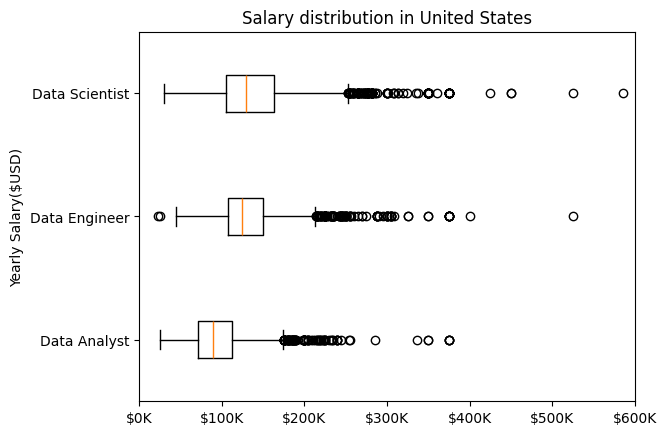

In [20]:
plt.boxplot(job_list,labels =job_titles,vert=False)
plt.title("Salary distribution in United States")
plt.xlabel("")
ax =plt.gca()
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x,pos:f'${int(x/1000)}K'))
plt.xlim(0,600000)
plt.ylabel("Yearly Salary($USD)")
plt.show()